# Deepinfer Test Data Overlap Report Colab

This is the single notebook artifact to share or push.

It contains:
- the metric code itself,
- the test-data evaluation workflow,
- the selected-slice explanation,
- the generated report photos directly in the notebook outputs.

It uses the existing local test run folder:
- `Deepinfer/test_data_run_20260326`


## Metrics Used

The 3 requested region-based metrics are:

- `Intersection`
- `Ground Truth Only`
- `Output Only`

For each one, the notebook shows both:
- raw `voxel` count
- normalized value in `0.xx` form

Normalized values are computed by dividing each region by the union:
- `intersection_ratio = intersection_voxels / union_voxels`
- `ground_truth_only_ratio = ground_truth_only_voxels / union_voxels`
- `prediction_only_ratio = prediction_only_voxels / union_voxels`

A voxel is one small 3D unit in the MRI volume.


In [1]:
from __future__ import annotations

import csv
import gzip
import math
import re
from dataclasses import dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['image.cmap'] = 'gray'
plt.rcParams['figure.figsize'] = (10, 8)

In [2]:
def looks_like_models_tested_dir(path: Path) -> bool:
    return (path / 'Deepinfer').exists()


CANDIDATE_DIRS = [
    Path.cwd(),
    Path.cwd() / 'Segmentation Models' / 'Models Tested',
    Path('Segmentation Models') / 'Models Tested',
]

MODELS_TESTED_DIR = next((path.resolve() for path in CANDIDATE_DIRS if looks_like_models_tested_dir(path)), None)
if MODELS_TESTED_DIR is None:
    raise FileNotFoundError('Could not find the Models Tested directory.')

DEEPINFER_DIR = MODELS_TESTED_DIR / 'Deepinfer'
RUN_DIR = DEEPINFER_DIR / 'test_data_run_20260326'
IMAGES_DIR = RUN_DIR / 'nrrd_images'
LABELS_DIR = RUN_DIR / 'nrrd_labels'
PREDICTION_DIR = RUN_DIR / 'deepinfer_predictions'

for path in [RUN_DIR, IMAGES_DIR, LABELS_DIR, PREDICTION_DIR]:
    if not path.exists():
        raise FileNotFoundError(f'Missing required path: {path}')

print('MODELS_TESTED_DIR =', MODELS_TESTED_DIR)
print('RUN_DIR =', RUN_DIR)
print('IMAGES_DIR =', IMAGES_DIR)
print('LABELS_DIR =', LABELS_DIR)
print('PREDICTION_DIR =', PREDICTION_DIR)

MODELS_TESTED_DIR = C:\Users\Administrator\Desktop\vipp\github\prostate-cancer-mri-grading\Segmentation Models\Models Tested
RUN_DIR = C:\Users\Administrator\Desktop\vipp\github\prostate-cancer-mri-grading\Segmentation Models\Models Tested\Deepinfer\test_data_run_20260326
IMAGES_DIR = C:\Users\Administrator\Desktop\vipp\github\prostate-cancer-mri-grading\Segmentation Models\Models Tested\Deepinfer\test_data_run_20260326\nrrd_images
LABELS_DIR = C:\Users\Administrator\Desktop\vipp\github\prostate-cancer-mri-grading\Segmentation Models\Models Tested\Deepinfer\test_data_run_20260326\nrrd_labels
PREDICTION_DIR = C:\Users\Administrator\Desktop\vipp\github\prostate-cancer-mri-grading\Segmentation Models\Models Tested\Deepinfer\test_data_run_20260326\deepinfer_predictions


In [3]:
TYPE_MAP = {
    'signed char': np.int8,
    'int8': np.int8,
    'char': np.int8,
    'uchar': np.uint8,
    'unsigned char': np.uint8,
    'uint8': np.uint8,
    'short': np.int16,
    'short int': np.int16,
    'signed short': np.int16,
    'signed short int': np.int16,
    'ushort': np.uint16,
    'unsigned short': np.uint16,
    'unsigned short int': np.uint16,
    'int': np.int32,
    'signed int': np.int32,
    'uint': np.uint32,
    'unsigned int': np.uint32,
    'float': np.float32,
    'double': np.float64,
}
CASE_PATTERN = re.compile(r'(Case\d+)', re.IGNORECASE)


@dataclass
class NrrdImage:
    path: Path
    data: np.ndarray
    sizes: tuple[int, ...]
    space_directions: tuple[tuple[float, ...], ...] | None
    space_origin: tuple[float, ...] | None


def parse_vector(value: str | None) -> tuple[float, ...] | None:
    if value is None:
        return None
    text = value.strip()
    if text.lower() == 'none':
        return None
    if not (text.startswith('(') and text.endswith(')')):
        raise ValueError(f'Cannot parse vector: {value}')
    return tuple(float(item) for item in text[1:-1].split(','))


def parse_vectors(value: str | None) -> tuple[tuple[float, ...], ...] | None:
    if value is None:
        return None
    parts = value.split(') (')
    normalized = []
    for part in parts:
        if not part.startswith('('):
            part = '(' + part
        if not part.endswith(')'):
            part = part + ')'
        normalized.append(parse_vector(part))
    return tuple(normalized)


def read_nrrd_header_and_payload(path: Path) -> tuple[dict[str, str], bytes]:
    header_lines: list[str] = []
    with path.open('rb') as stream:
        magic = stream.readline().decode('ascii').strip()
        if not magic.startswith('NRRD'):
            raise ValueError(f'{path}: not a NRRD file')
        header_lines.append(magic)

        while True:
            line = stream.readline()
            if not line:
                raise ValueError(f'{path}: incomplete NRRD header')
            if line.strip() == b'':
                break
            header_lines.append(line.decode('ascii').rstrip('\r\n'))

        payload = stream.read()

    header: dict[str, str] = {}
    for line in header_lines[1:]:
        if not line or line.startswith('#') or ': ' not in line:
            continue
        key, value = line.split(': ', 1)
        header[key.strip().lower()] = value.strip()

    required = {'type', 'dimension', 'sizes'}
    missing = required - header.keys()
    if missing:
        raise ValueError(f'{path}: missing NRRD fields {sorted(missing)}')

    return header, payload


def build_dtype(header: dict[str, str]) -> np.dtype:
    type_name = header['type'].strip().lower()
    if type_name not in TYPE_MAP:
        raise ValueError(f"Unsupported NRRD type: {header['type']}")

    dtype = np.dtype(TYPE_MAP[type_name])
    if dtype.itemsize == 1:
        return dtype

    endian = header.get('endian', '').strip().lower()
    if endian == 'little':
        return dtype.newbyteorder('<')
    if endian == 'big':
        return dtype.newbyteorder('>')
    raise ValueError('NRRD endian field is required for multi-byte voxel types')


def read_nrrd(path: Path) -> NrrdImage:
    header, payload = read_nrrd_header_and_payload(path)
    sizes = tuple(int(value) for value in header['sizes'].split())
    dtype = build_dtype(header)
    encoding = header.get('encoding', 'raw').strip().lower()

    if encoding in {'gzip', 'gz'}:
        payload = gzip.decompress(payload)
    elif encoding != 'raw':
        raise ValueError(f"{path}: unsupported NRRD encoding '{encoding}'")

    voxel_count = math.prod(sizes)
    expected_bytes = voxel_count * dtype.itemsize
    if len(payload) != expected_bytes:
        raise ValueError(f'{path}: expected {expected_bytes} bytes from header, found {len(payload)}')

    data = np.frombuffer(payload, dtype=dtype, count=voxel_count).copy()
    data = data.reshape(tuple(reversed(sizes)))

    return NrrdImage(
        path=path,
        data=data,
        sizes=sizes,
        space_directions=parse_vectors(header.get('space directions')),
        space_origin=parse_vector(header.get('space origin')),
    )


def case_id(path: Path) -> str:
    match = CASE_PATTERN.search(path.stem)
    if not match:
        raise ValueError(f'Cannot extract case id from filename: {path.name}')
    return match.group(1)


def collect_cases(directory: Path) -> dict[str, Path]:
    return {case_id(path): path for path in sorted(directory.glob('*.nrrd'))}


def geometry_matches(image_a: NrrdImage, image_b: NrrdImage, tolerance: float) -> tuple[bool, str]:
    if image_a.sizes != image_b.sizes:
        return False, f'size mismatch: {image_a.sizes} vs {image_b.sizes}'

    if image_a.space_origin is not None and image_b.space_origin is not None:
        if not all(math.isclose(a, b, abs_tol=tolerance) for a, b in zip(image_a.space_origin, image_b.space_origin)):
            return False, 'space origin mismatch'

    if image_a.space_directions is not None and image_b.space_directions is not None:
        for vec_a, vec_b in zip(image_a.space_directions, image_b.space_directions):
            if vec_a is None or vec_b is None:
                continue
            if not all(math.isclose(a, b, abs_tol=tolerance) for a, b in zip(vec_a, vec_b)):
                return False, 'space directions mismatch'

    return True, 'ok'

In [4]:
METRIC_SPECS = (
    ('intersection_voxels', 'intersection_ratio', 'Intersection', (0.12, 0.75, 0.29, 0.55)),
    ('ground_truth_only_voxels', 'ground_truth_only_ratio', 'Ground Truth Only', (1.0, 0.64, 0.12, 0.55)),
    ('prediction_only_voxels', 'prediction_only_ratio', 'Output Only', (0.90, 0.16, 0.16, 0.55)),
)
VISUALIZATION_CASES = ['Case20', 'Case14', 'Case18']


def compute_overlap_metrics(ground_truth: np.ndarray, prediction: np.ndarray) -> dict[str, float | int]:
    gt_mask = ground_truth > 0
    pred_mask = prediction > 0

    intersection = gt_mask & pred_mask
    ground_truth_only = gt_mask & ~pred_mask
    prediction_only = pred_mask & ~gt_mask
    union = gt_mask | pred_mask

    intersection_voxels = int(np.count_nonzero(intersection))
    ground_truth_only_voxels = int(np.count_nonzero(ground_truth_only))
    prediction_only_voxels = int(np.count_nonzero(prediction_only))
    union_voxels = int(np.count_nonzero(union))

    return {
        'gt_voxels': int(np.count_nonzero(gt_mask)),
        'pred_voxels': int(np.count_nonzero(pred_mask)),
        'intersection_voxels': intersection_voxels,
        'ground_truth_only_voxels': ground_truth_only_voxels,
        'prediction_only_voxels': prediction_only_voxels,
        'union_voxels': union_voxels,
        'intersection_ratio': (intersection_voxels / union_voxels) if union_voxels else 1.0,
        'ground_truth_only_ratio': (ground_truth_only_voxels / union_voxels) if union_voxels else 0.0,
        'prediction_only_ratio': (prediction_only_voxels / union_voxels) if union_voxels else 0.0,
    }


def compute_case_rows(labels_dir: Path, prediction_dir: Path, tolerance: float = 1e-6) -> list[dict[str, object]]:
    gt_cases = collect_cases(labels_dir.resolve())
    pred_cases = collect_cases(prediction_dir.resolve())
    common_cases = sorted(set(gt_cases) & set(pred_cases))

    rows: list[dict[str, object]] = []
    for case in common_cases:
        gt_image = read_nrrd(gt_cases[case])
        pred_image = read_nrrd(pred_cases[case])
        geometry_ok, geometry_note = geometry_matches(gt_image, pred_image, tolerance)
        metrics = compute_overlap_metrics(gt_image.data, pred_image.data)
        rows.append({'case': case, 'geometry_ok': geometry_ok, 'geometry_note': geometry_note, **metrics})
    return rows


def build_summary_rows(rows: list[dict[str, object]]) -> list[dict[str, object]]:
    return [
        {
            'metric': 'Intersection',
            'mean_ratio': float(np.mean([row['intersection_ratio'] for row in rows])),
            'mean_voxels': float(np.mean([row['intersection_voxels'] for row in rows])),
        },
        {
            'metric': 'Ground Truth Only',
            'mean_ratio': float(np.mean([row['ground_truth_only_ratio'] for row in rows])),
            'mean_voxels': float(np.mean([row['ground_truth_only_voxels'] for row in rows])),
        },
        {
            'metric': 'Output Only',
            'mean_ratio': float(np.mean([row['prediction_only_ratio'] for row in rows])),
            'mean_voxels': float(np.mean([row['prediction_only_voxels'] for row in rows])),
        },
    ]


def normalize_image(image: np.ndarray) -> np.ndarray:
    lower = float(np.percentile(image, 1))
    upper = float(np.percentile(image, 99))
    if upper <= lower:
        return np.zeros_like(image, dtype=np.float32)
    clipped = np.clip(image.astype(np.float32), lower, upper)
    return (clipped - lower) / (upper - lower)


def best_slice_index(ground_truth: np.ndarray, prediction: np.ndarray) -> int:
    union = (ground_truth > 0) | (prediction > 0)
    per_slice = np.count_nonzero(union, axis=(1, 2))
    if np.max(per_slice) == 0:
        return union.shape[0] // 2
    return int(np.argmax(per_slice))


def selected_slice_rows(cases: list[str]) -> list[dict[str, object]]:
    image_cases = collect_cases(IMAGES_DIR.resolve())
    label_cases = collect_cases(LABELS_DIR.resolve())
    prediction_cases = collect_cases(PREDICTION_DIR.resolve())
    rows: list[dict[str, object]] = []
    for case in cases:
        image = read_nrrd(image_cases[case]).data
        ground_truth = read_nrrd(label_cases[case]).data > 0
        prediction = read_nrrd(prediction_cases[case]).data > 0
        rows.append(
            {
                'case': case,
                'axial_slice_index': best_slice_index(ground_truth, prediction),
                'num_slices': int(image.shape[0]),
            }
        )
    return rows


def render_metric_grid(cases: list[str]):
    image_cases = collect_cases(IMAGES_DIR.resolve())
    label_cases = collect_cases(LABELS_DIR.resolve())
    prediction_cases = collect_cases(PREDICTION_DIR.resolve())

    figure_data = []
    for case in cases:
        image = read_nrrd(image_cases[case]).data
        ground_truth = read_nrrd(label_cases[case]).data > 0
        prediction = read_nrrd(prediction_cases[case]).data > 0

        slice_index = best_slice_index(ground_truth, prediction)
        image_slice = normalize_image(image[slice_index])
        gt_slice = ground_truth[slice_index]
        pred_slice = prediction[slice_index]
        union_slice = int(np.count_nonzero(gt_slice | pred_slice))

        metric_masks = {
            'intersection_voxels': gt_slice & pred_slice,
            'ground_truth_only_voxels': gt_slice & ~pred_slice,
            'prediction_only_voxels': pred_slice & ~gt_slice,
        }
        metric_counts = {key: int(np.count_nonzero(mask)) for key, mask in metric_masks.items()}
        metric_ratios = {
            'intersection_ratio': (metric_counts['intersection_voxels'] / union_slice) if union_slice else 1.0,
            'ground_truth_only_ratio': (metric_counts['ground_truth_only_voxels'] / union_slice) if union_slice else 0.0,
            'prediction_only_ratio': (metric_counts['prediction_only_voxels'] / union_slice) if union_slice else 0.0,
        }

        figure_data.append(
            {
                'case': case,
                'slice_index': slice_index,
                'image_slice': image_slice,
                'gt_slice': gt_slice,
                'pred_slice': pred_slice,
                'metric_masks': metric_masks,
                'metric_counts': metric_counts,
                'metric_ratios': metric_ratios,
            }
        )

    fig, axes = plt.subplots(nrows=len(figure_data), ncols=len(METRIC_SPECS), figsize=(14.0, 4.2 * len(figure_data)), dpi=200)
    axes = np.atleast_2d(axes)

    for row_index, case_data in enumerate(figure_data):
        for column_index, (count_key, ratio_key, title, color) in enumerate(METRIC_SPECS):
            ax = axes[row_index, column_index]
            ax.imshow(case_data['image_slice'], cmap='gray', interpolation='nearest')

            overlay = np.zeros((*case_data['image_slice'].shape, 4), dtype=np.float32)
            overlay[case_data['metric_masks'][count_key]] = color
            ax.imshow(overlay, interpolation='nearest')

            ax.contour(case_data['gt_slice'].astype(np.uint8), levels=[0.5], colors=['lime'], linewidths=0.6)
            ax.contour(case_data['pred_slice'].astype(np.uint8), levels=[0.5], colors=['red'], linewidths=0.6)

            ax.set_title(
                f"{case_data['case']} | slice {case_data['slice_index']}\n{title}\n{case_data['metric_ratios'][ratio_key]:.4f} | {case_data['metric_counts'][count_key]:,} voxels",
                fontsize=10,
            )
            ax.axis('off')

    fig.suptitle('Deepinfer Metrics: green contours = ground truth, red contours = prediction', fontsize=13, y=0.995)
    fig.tight_layout(rect=(0.03, 0.0, 1.0, 0.98))
    return fig


def build_report_figure(summary_df: pd.DataFrame, visualization_figure):
    visualization_figure.canvas.draw()
    width, height = visualization_figure.canvas.get_width_height()
    image = np.frombuffer(visualization_figure.canvas.buffer_rgba(), dtype=np.uint8).reshape(height, width, 4)

    fig = plt.figure(figsize=(15, 15), dpi=200)
    grid = fig.add_gridspec(2, 1, height_ratios=[0.8, 2.8])

    ax_table = fig.add_subplot(grid[0])
    ax_table.axis('off')
    table_values = [
        [row['metric'], f"{row['mean_ratio']:.4f}", f"{row['mean_voxels']:.2f}"]
        for _, row in summary_df.iterrows()
    ]
    table = ax_table.table(
        cellText=table_values,
        colLabels=['Metric', 'Mean Normalized', 'Mean Voxels'],
        cellLoc='center',
        loc='center',
    )
    table.auto_set_font_size(False)
    table.set_fontsize(11)
    table.scale(1.0, 1.7)
    ax_table.set_title('Deepinfer Test Data Overlap Metrics Mean Results', fontsize=14, weight='bold', pad=12)

    ax_image = fig.add_subplot(grid[1])
    ax_image.imshow(image)
    ax_image.axis('off')
    ax_image.set_title('Representative Test-Case Visualization', fontsize=13, pad=8)

    fig.tight_layout(rect=(0, 0, 1, 0.98))
    return fig

In [5]:
rows = compute_case_rows(LABELS_DIR, PREDICTION_DIR, tolerance=1e-6)
metrics_df = pd.DataFrame(rows).sort_values('case').reset_index(drop=True)
summary_df = pd.DataFrame(build_summary_rows(rows))

print('Number of evaluated test cases:', len(metrics_df))
display(
    metrics_df[
        [
            'case',
            'intersection_ratio',
            'ground_truth_only_ratio',
            'prediction_only_ratio',
            'intersection_voxels',
            'ground_truth_only_voxels',
            'prediction_only_voxels',
        ]
    ].round(
        {
            'intersection_ratio': 4,
            'ground_truth_only_ratio': 4,
            'prediction_only_ratio': 4,
        }
    )
)

Number of evaluated test cases: 30


,case,intersection_ratio,ground_truth_only_ratio,prediction_only_ratio,intersection_voxels,ground_truth_only_voxels,prediction_only_voxels
0,Case00,0.8757,0.0652,0.0591,64478,4800,4349
1,Case01,0.8002,0.1460,0.0537,32559,5942,2186
2,Case02,0.8446,0.1082,0.0472,46631,5976,2604
3,Case03,0.8523,0.1213,0.0264,70967,10097,2201
4,Case04,0.8590,0.0841,0.0569,47008,4605,3113
5,Case05,0.7942,0.1772,0.0286,63965,14267,2304
6,Case06,0.8119,0.1015,0.0866,25092,3138,2677
7,Case07,0.8089,0.1192,0.0719,80323,11839,7140
8,Case08,0.7698,0.1927,0.0375,114747,28718,5597
9,Case09,0.6372,0.3572,0.0056,60592,33967,529


In [6]:
display(summary_df.assign(mean_ratio=summary_df['mean_ratio'].round(4), mean_voxels=summary_df['mean_voxels'].round(2)))

,metric,mean_ratio,mean_voxels
0,Intersection,0.7363,60953.40
1,Ground Truth Only,0.1986,23266.63
2,Output Only,0.0651,4331.03


## Selected Visualization Slices

Each case is a 3D MRI volume made of many axial slices.

The notebook computes the metrics on the full 3D masks, but for visualization it shows one representative axial slice per case. The selected slice is the slice where the union of ground truth and prediction is largest.

In [7]:
slice_df = pd.DataFrame(selected_slice_rows(VISUALIZATION_CASES))
display(slice_df)

,case,axial_slice_index,num_slices
0,Case20,12,23
1,Case14,10,23
2,Case18,12,25


## Visualization Photo

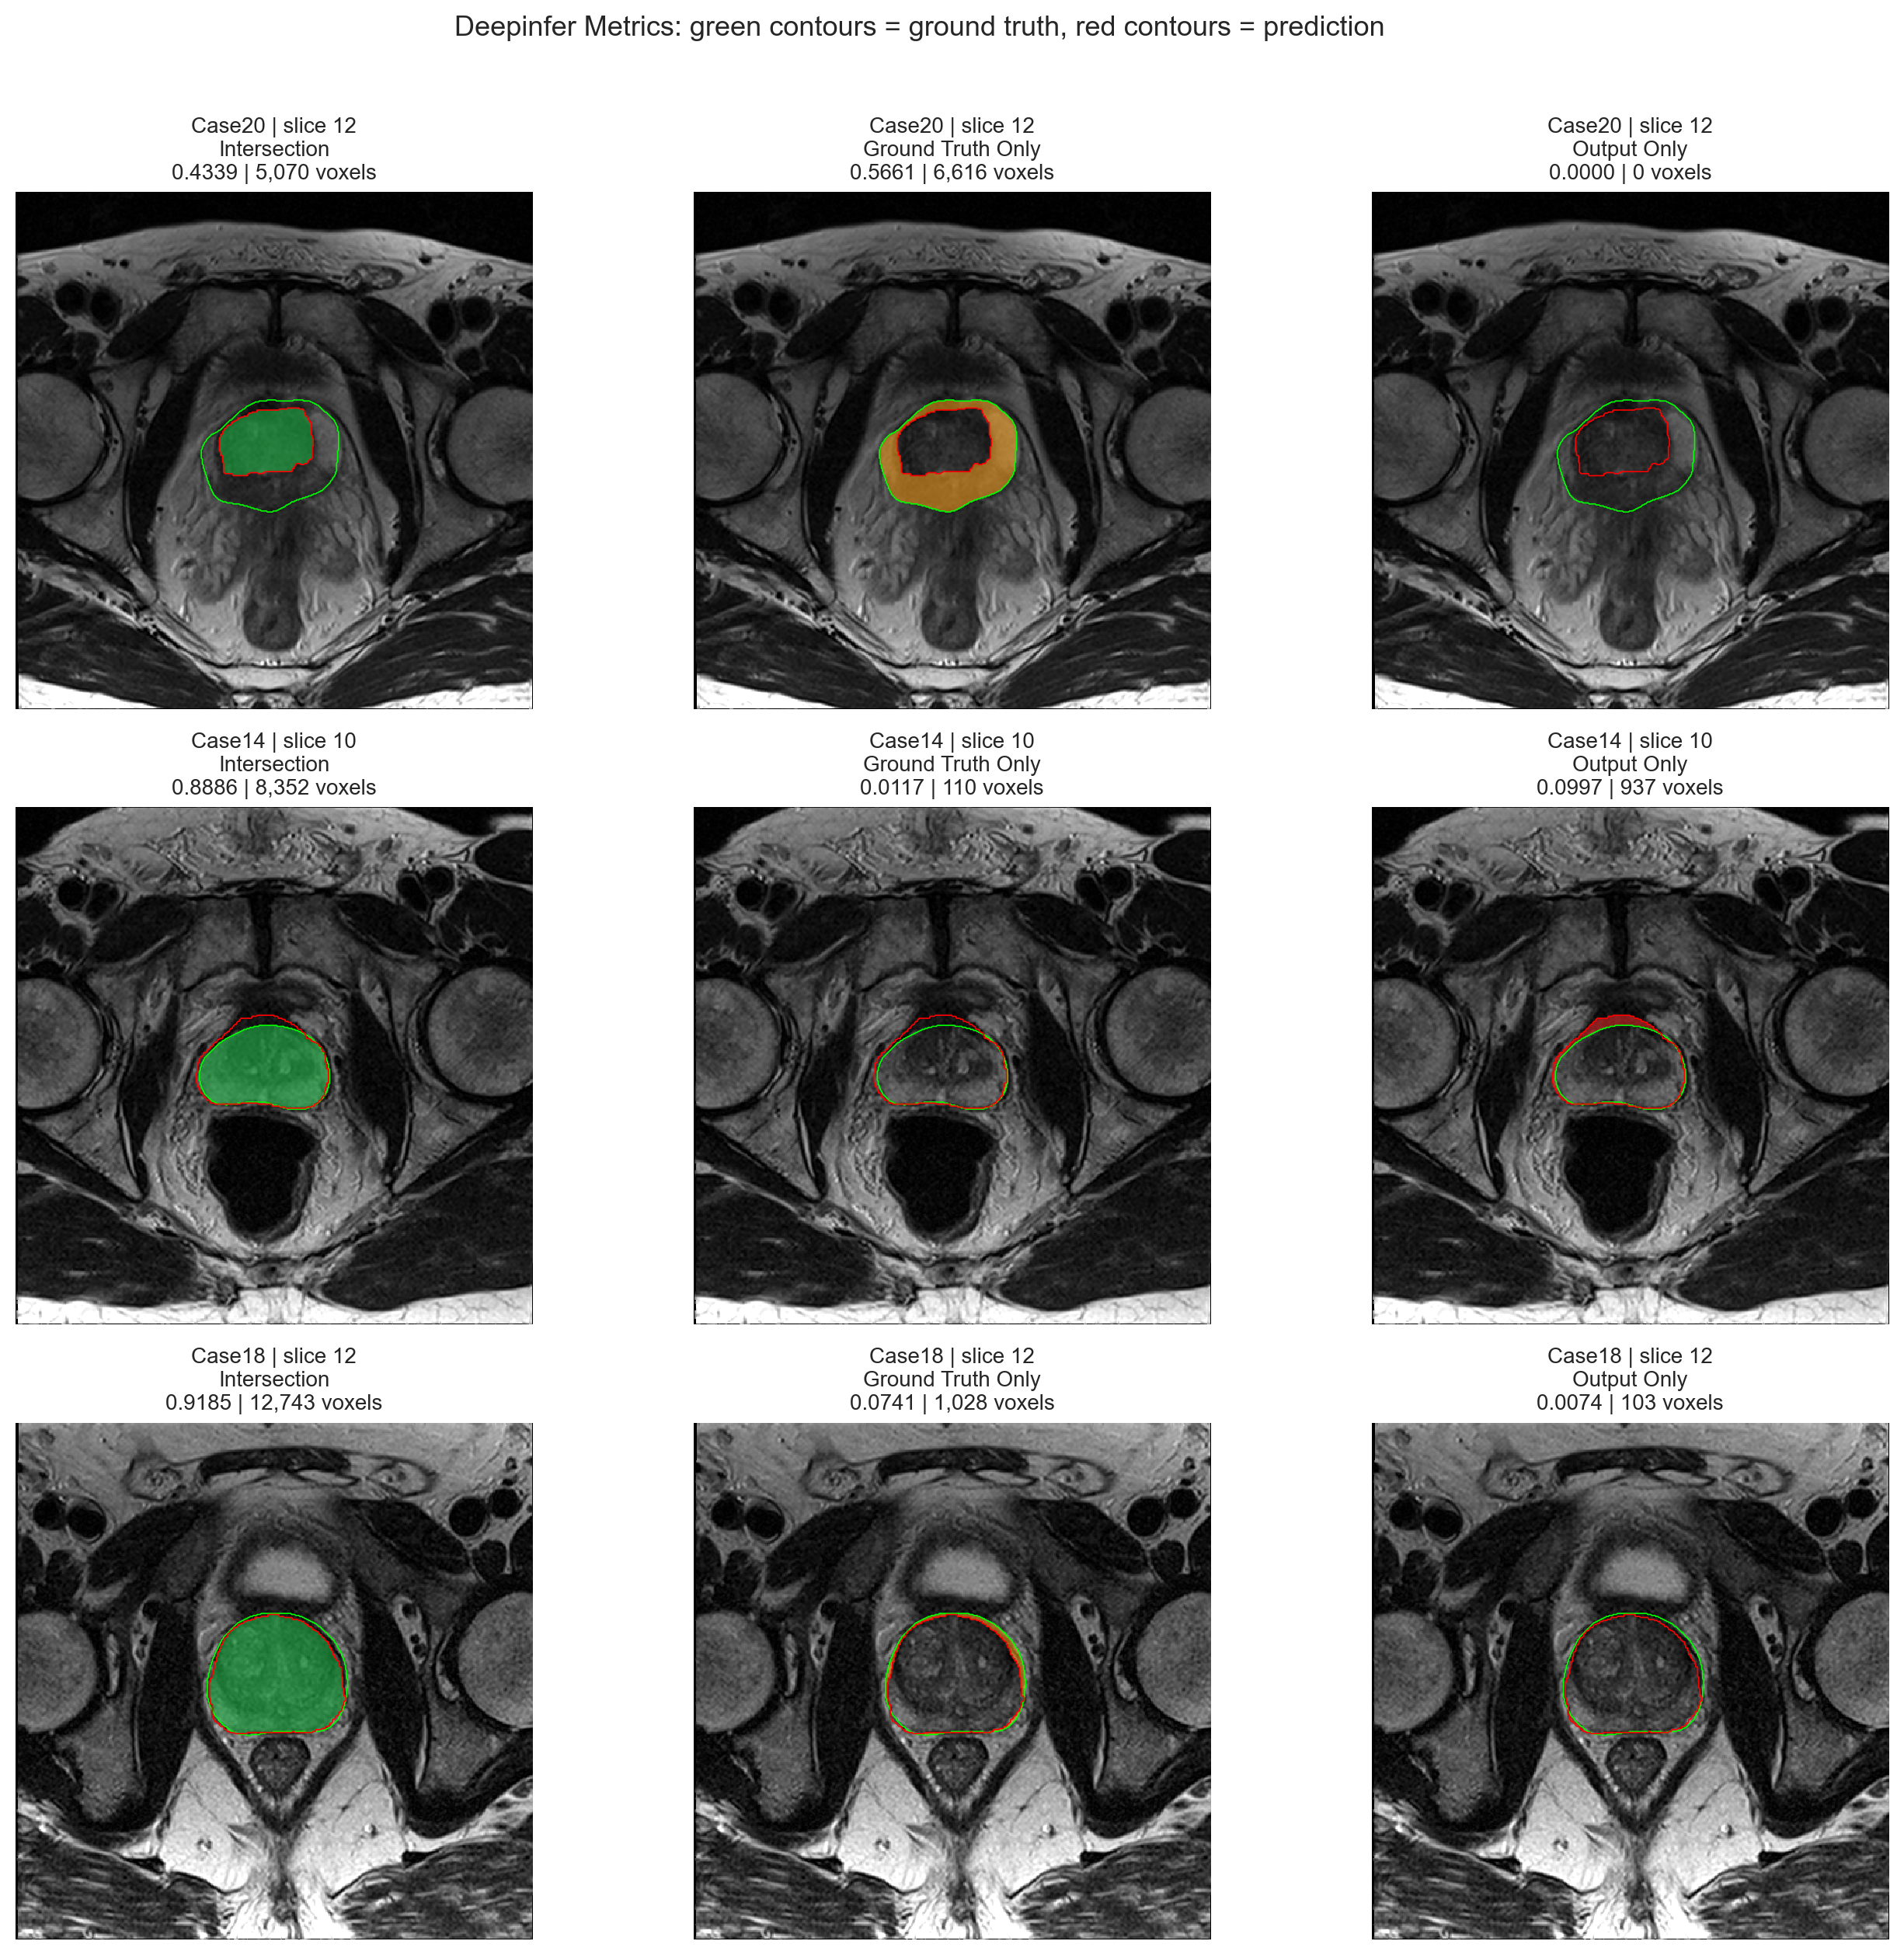

In [8]:
visualization_fig = render_metric_grid(VISUALIZATION_CASES)
plt.show()

## Final Report Photo

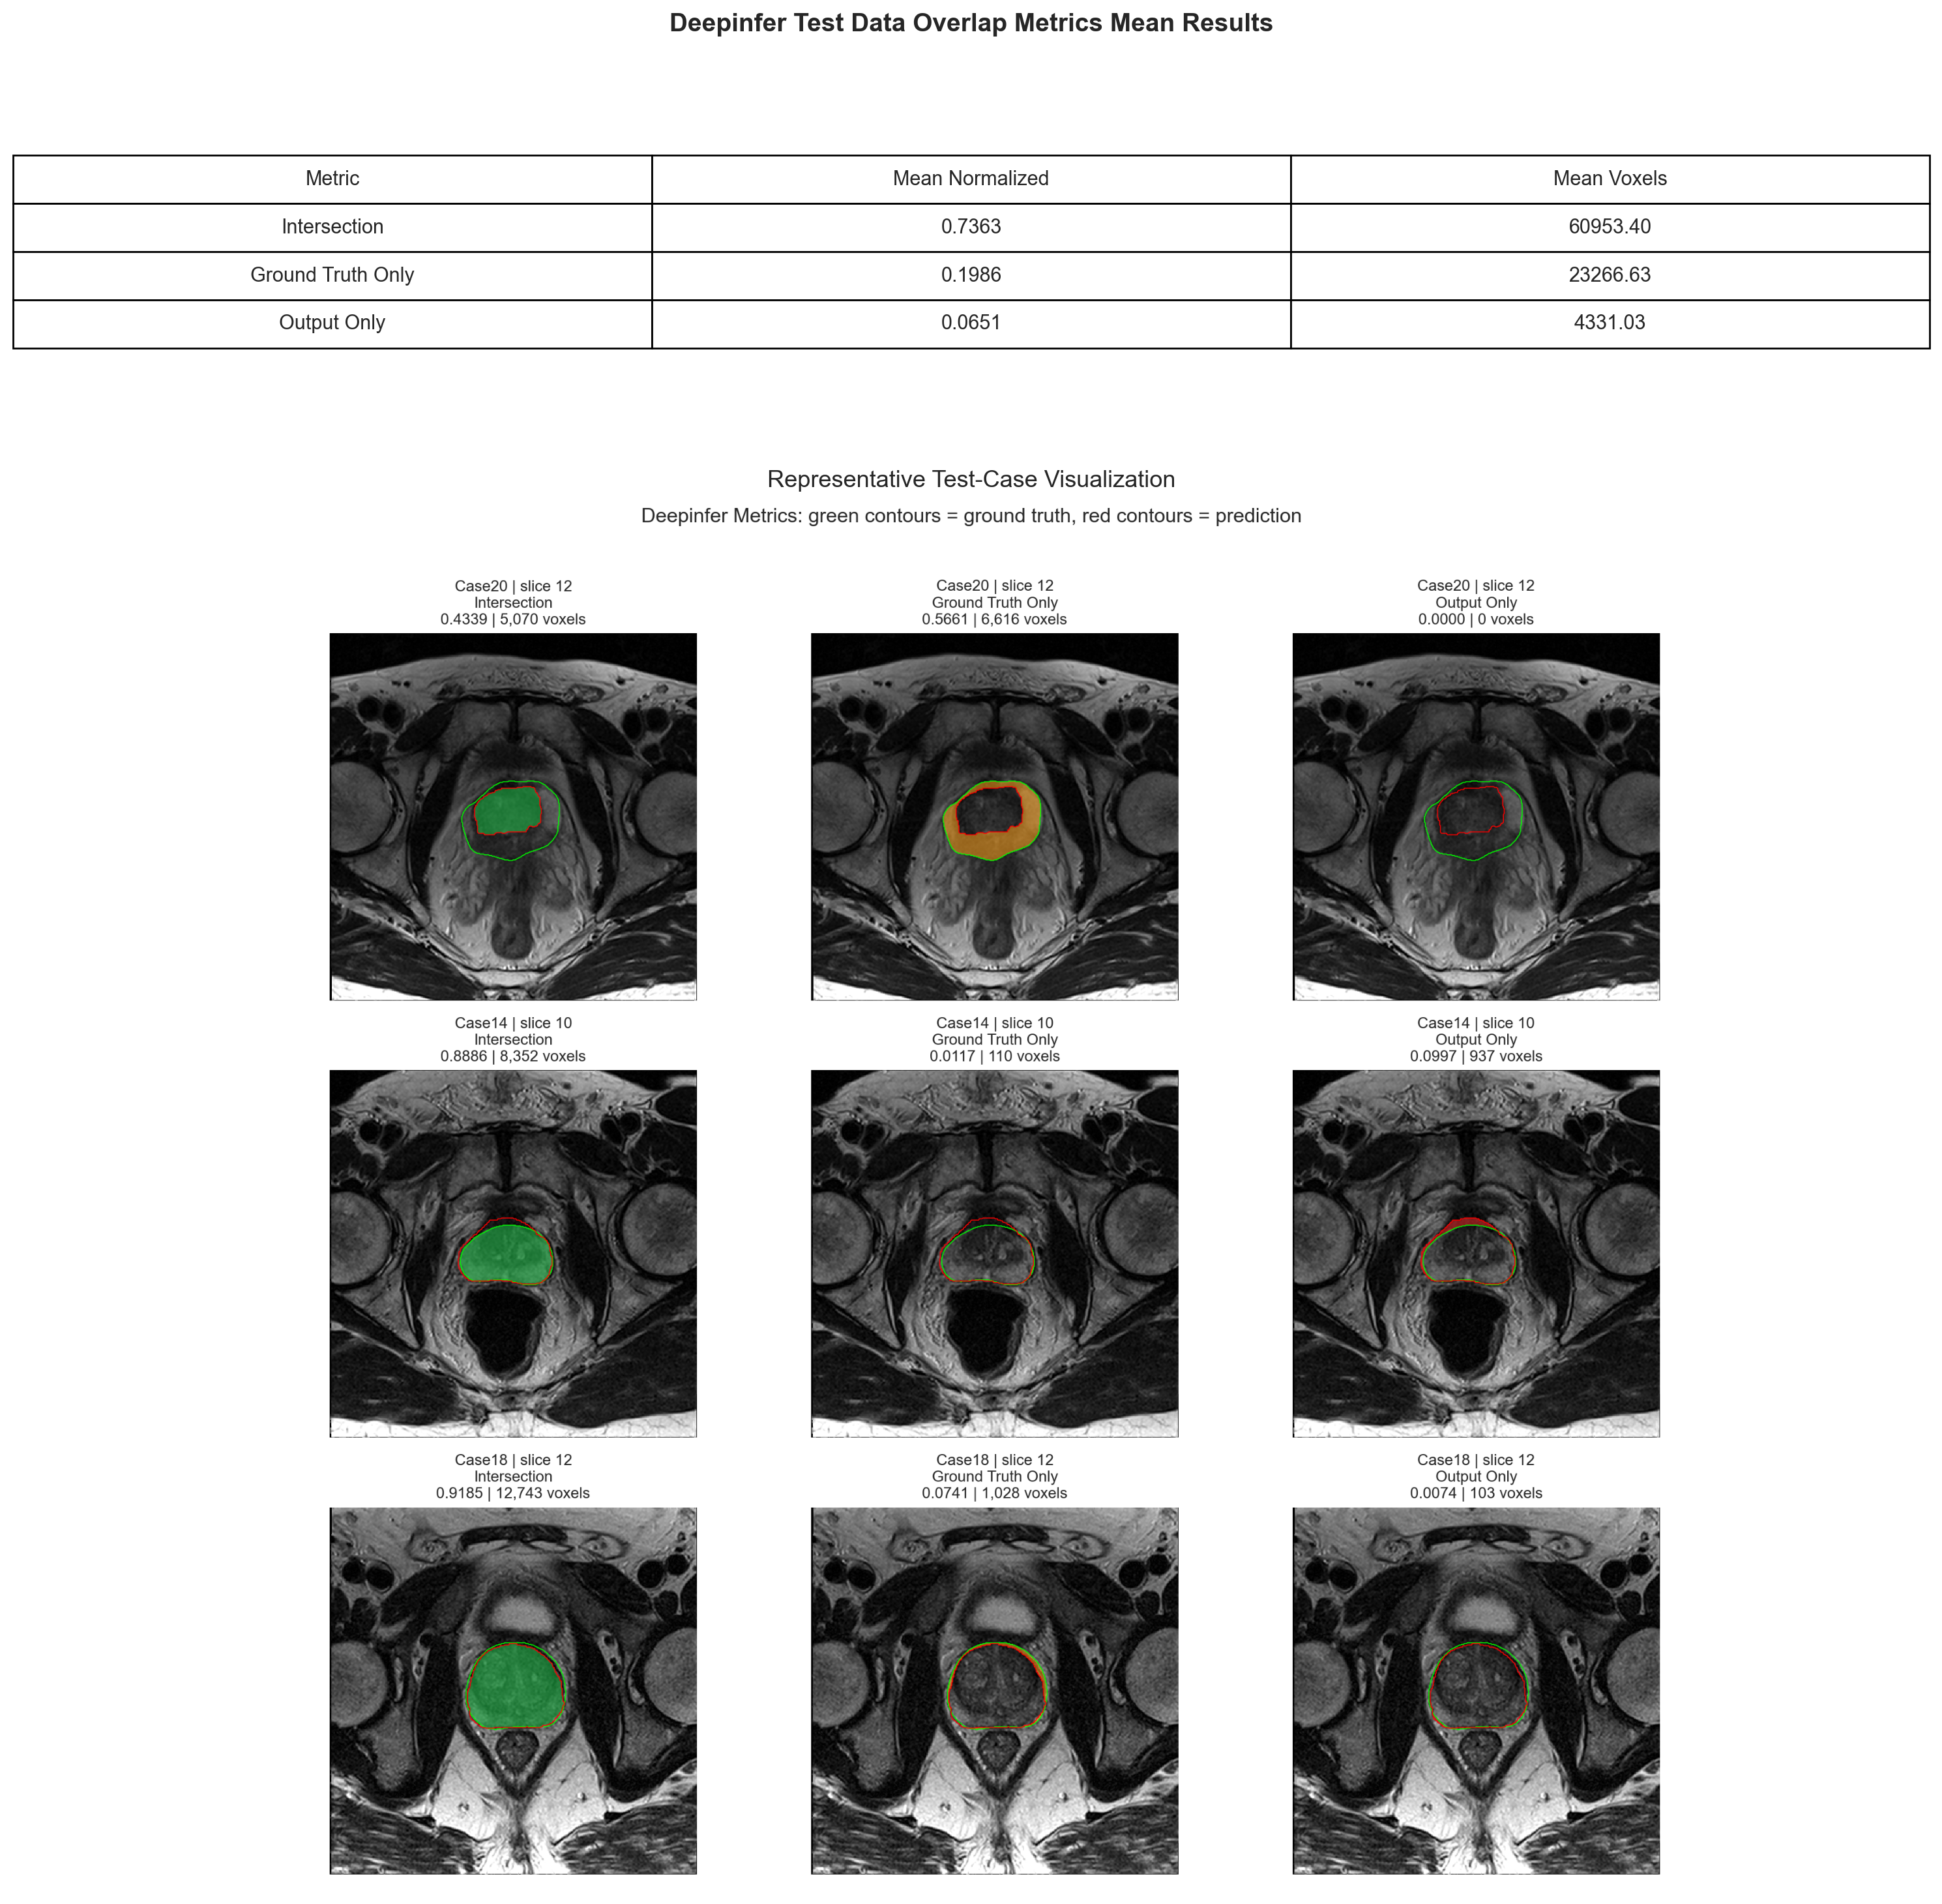

In [9]:
report_fig = build_report_figure(summary_df, visualization_fig)
plt.show()